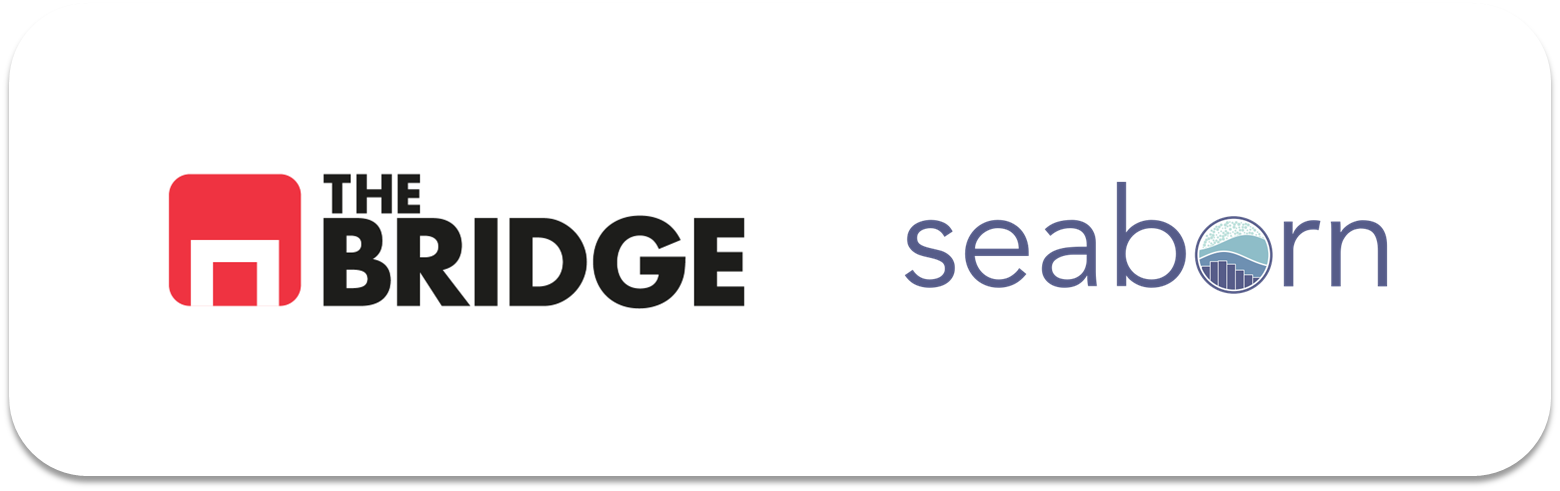

## PRACTICA OBLIGATORIA: **Visualización y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math

## #1 VISUALIZACION

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [2]:
df_cities = pd.read_csv("./data/california_cities.csv")
df_cities

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA OPCIONAL: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños.

In [3]:
def scatter_with_controls(df, x_col, y_col, color_col=None,
                          size_col=None, scale=1, legend=True):
    """
    Pinta un diagrama de dispersión con:
    - color opcional por columna categórica
    - tamaño fijo o basado en una columna numérica
    - escala para ajustar el tamaño cuando size_col es columna
    """

    fig, ax = plt.subplots(figsize=(12, 6))

    # Diccionario base
    plot_kwargs = {
        "data": df,
        "x": x_col,
        "y": y_col,
        "alpha": 0.6,
        "ax": ax
    }

    # --- Color opcional ---
    if color_col is not None:
        plot_kwargs["hue"] = color_col
        plot_kwargs["palette"] = "viridis"

    # --- Tamaño: numérico fijo o columna ---
    if size_col is not None:

        # Si es una columna → usarla como size
        if isinstance(size_col, str):
            plot_kwargs["size"] = size_col
            plot_kwargs["sizes"] = (20 * scale, 800 * scale)

        # Si es un número → tamaño fijo
        else:
            plot_kwargs["size"] = None
            plot_kwargs["s"] = size_col * scale

    # --- Dibujar scatter ---
    sns.scatterplot(**plot_kwargs)

    # --- Leyenda ---
    if legend:
        ax.legend(loc="upper right", frameon=False)
    else:
        leg = ax.get_legend()
        if leg:
            leg.remove()

    # --- Etiquetas ---
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    plt.tight_layout()
    plt.show()


### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Una vez calculado el logaritmo, también puedes probar a categorizar la población, aquí tienes un ejemplo de como podría salir para que lo tengas de referencia:

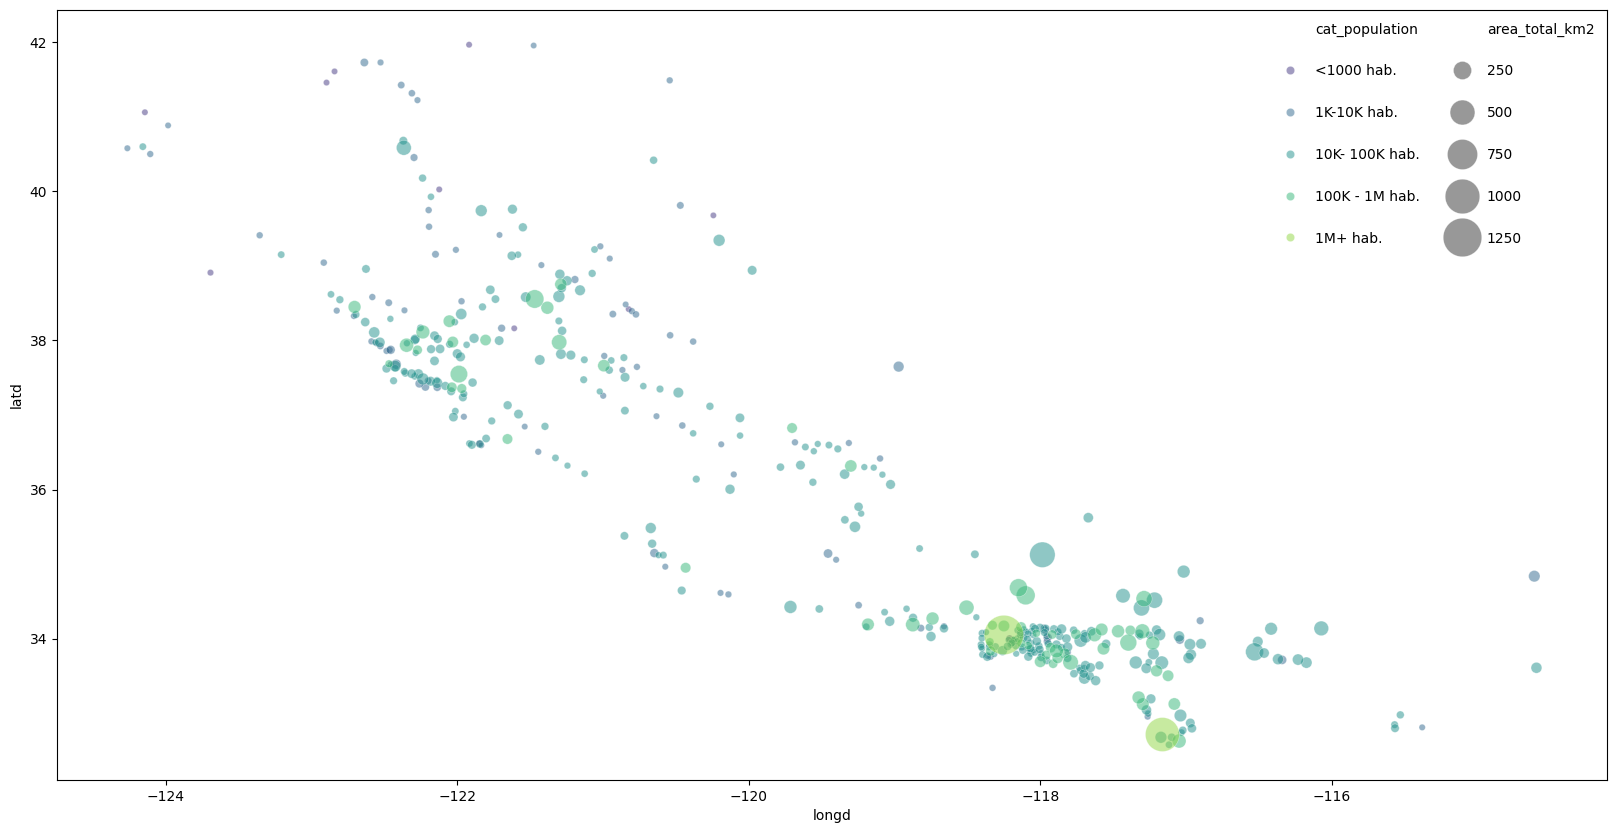

In [5]:
# 1. Crear columna logarítmica
df_cities["log_poblacion"] = np.log10(df_cities["population_total"])

In [6]:
df_cities.head(2)

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent,log_poblacion
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03,4.501949
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37,4.308137


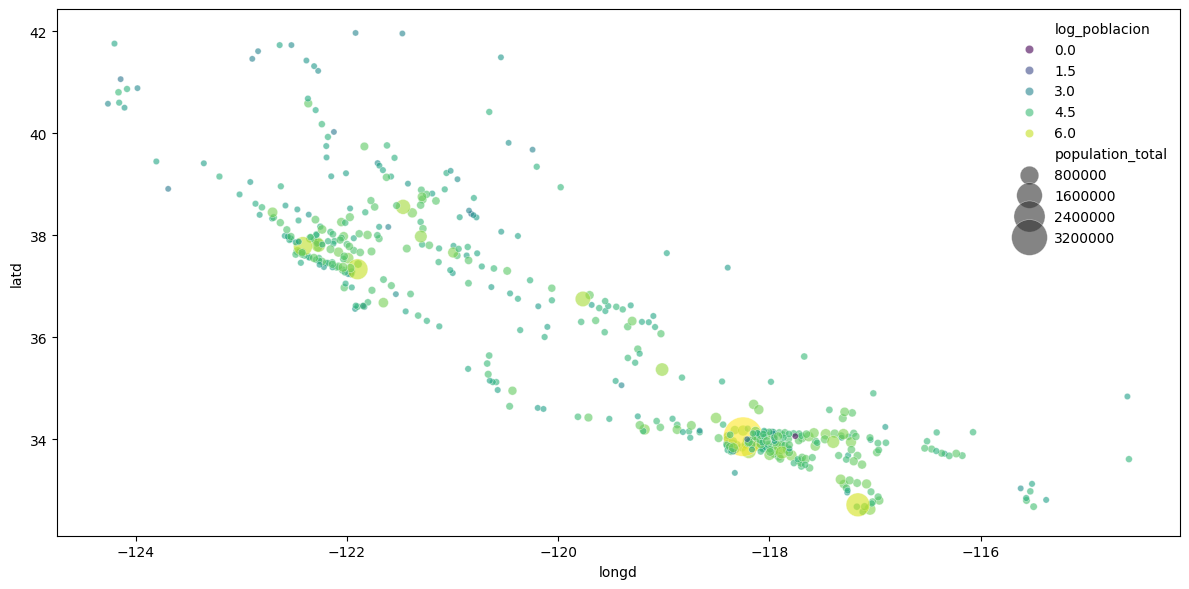

In [9]:
scatter_with_controls(
    df=df_cities,
    x_col="longd",          # eje X → longitud
    y_col="latd",           # eje Y → latitud
    color_col="log_poblacion", # color → población en escala log
    size_col="population_total",# tamaño → población real
    scale=1,              # escala para que los tamaños no exploten
    legend=True                 # mostrar leyenda
)


## #2: Presentación

En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

In [3]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


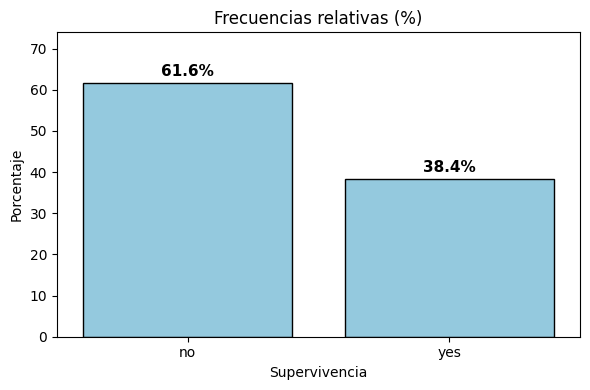

,Frecuencia (%)
alive,
no,61.616162
yes,38.383838


In [4]:
variable_categorica = "alive"
df = df_titanic

# Calcular frecuencias relativas
freq_rel = df[variable_categorica].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))

# Gráfico de barras
ax = sns.barplot(
    x=freq_rel.index,
    y=freq_rel.values,
    color="skyblue",
    edgecolor="black"
)

# Título y ejes
plt.title("Frecuencias relativas (%)")
plt.xlabel("Supervivencia")
plt.ylabel("Porcentaje")

# Añadir porcentajes encima de cada barra
for i, valor in enumerate(freq_rel.values):
    ax.text(
        i,
        valor + 1,                      
        f"{valor:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, freq_rel.max() * 1.20)
plt.tight_layout()
plt.show()

# Mostrar tabla de frecuencias relativas
freq_rel.to_frame(name="Frecuencia (%)")


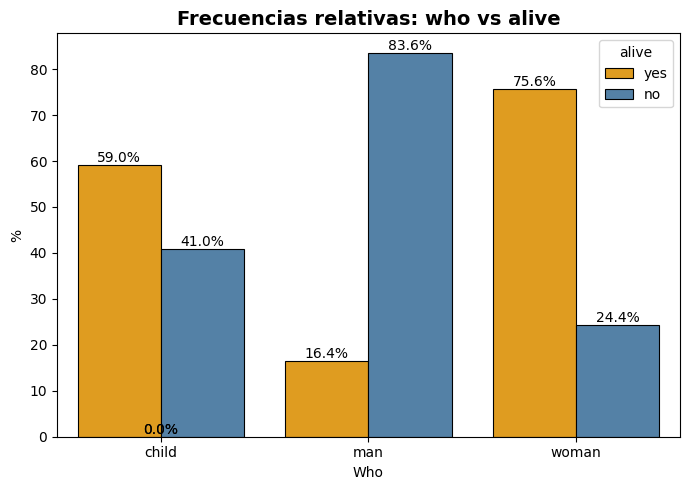

In [5]:
### FRECUENCIAS RELATIVAS ENTRE VARIABLE CATEGÓRICA Y BINARIA

variable_categorica = "who"
variable_binaria    = "alive"
df = df_titanic

# Calcular tabla de porcentajes
tabla = (
    df.groupby(variable_categorica)[variable_binaria]
      .value_counts(normalize=True)
      .rename("porcentaje")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla,
    x=variable_categorica,
    y="porcentaje",
    hue=variable_binaria,
    palette=["orange", "steelblue"],
    edgecolor="black",
    linewidth=0.8
)

plt.title(f"Frecuencias relativas: {variable_categorica} vs {variable_binaria}",
          fontsize=14, weight="bold")
plt.ylabel("%")
plt.xlabel(variable_categorica.capitalize())

# --- Añadir números encima de cada barra ---
for p in ax.patches:
    valor = p.get_height()
    ax.annotate(f"{valor:.1f}%",
                (p.get_x() + p.get_width() / 2, valor),
                ha='center', va='bottom',
                fontsize=10)

plt.tight_layout()
plt.show()


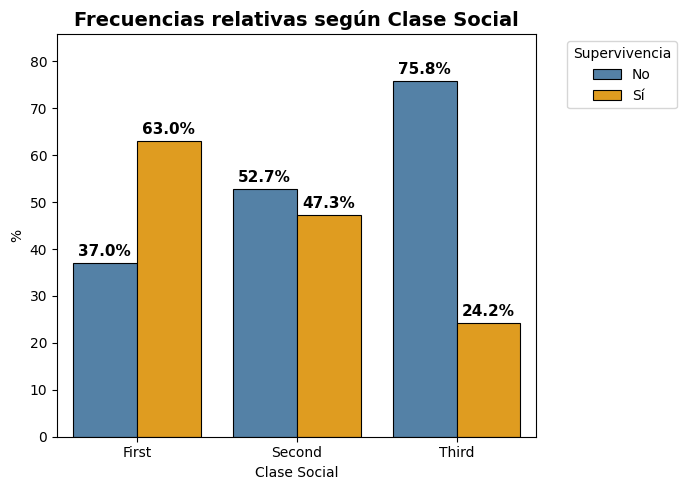

In [8]:
### FRECUENCIAS RELATIVAS ENTRE VARIABLE CATEGÓRICA Y BINARIA

variable_categorica = "class"
variable_binaria    = "alive" 
df = df_titanic.copy()

# Cambiar valores de la variable binaria a "Sí" y "No"
df[variable_binaria] = df[variable_binaria].map({"yes": "Sí", "no": "No"})

# Orden manual del hue
orden_hue = ["No", "Sí"]

# Calcular tabla de porcentajes
tabla = (
    df.groupby(variable_categorica)[variable_binaria]
      .value_counts(normalize=True)
      .rename("porcentaje")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla,
    x=variable_categorica,
    y="porcentaje",
    hue=variable_binaria,
    hue_order=orden_hue,                 # ← clave para que respete el orden
    palette=["steelblue", "orange"],     # ← colores en el mismo orden
    edgecolor="black",
    linewidth=0.8
)

plt.title("Frecuencias relativas según Clase Social", fontsize=14, weight="bold")
plt.ylabel("%")
plt.xlabel("Clase Social")

# --- Ajustar límite superior del eje Y ---
max_val = tabla["porcentaje"].max()
ax.set_ylim(0, max_val + 10)

# --- Leyenda personalizada ---
ax.legend(
    title="Supervivencia",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

# --- Añadir números encima de cada barra ---
for p in ax.patches:
    valor = p.get_height()
    if valor > 0.1:
        ax.annotate(
            f"{valor:.1f}%",
            (p.get_x() + p.get_width() / 2, valor),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.tight_layout()
plt.show()

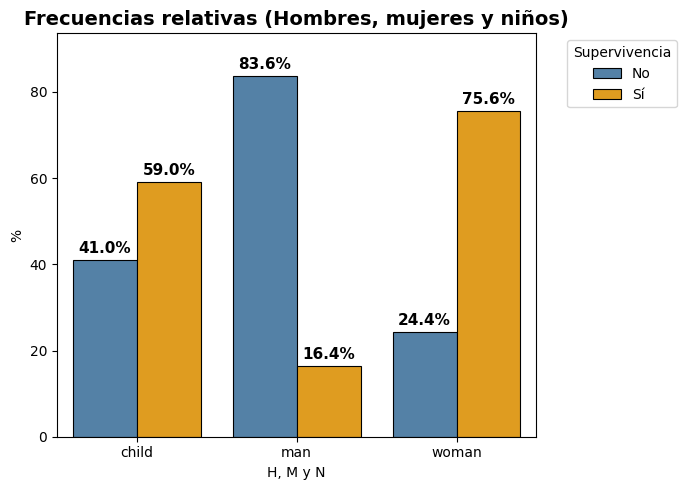

In [20]:
### FRECUENCIAS RELATIVAS ENTRE VARIABLE CATEGÓRICA Y BINARIA

variable_categorica = "who"
variable_binaria    = "alive" 
df = df_titanic.copy()

# Cambiar valores de la variable binaria a "Sí" y "No"
df[variable_binaria] = df[variable_binaria].map({"yes": "Sí", "no": "No"})

# Orden manual del hue
orden_hue = ["No", "Sí"]

# Calcular tabla de porcentajes
tabla = (
    df.groupby(variable_categorica)[variable_binaria]
      .value_counts(normalize=True)
      .rename("porcentaje")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla,
    x=variable_categorica,
    y="porcentaje",
    hue=variable_binaria,
    hue_order=orden_hue,                 # ← clave para que respete el orden
    palette=["steelblue", "orange"],     # ← colores en el mismo orden
    edgecolor="black",
    linewidth=0.8
)

plt.title("Frecuencias relativas (Hombres, mujeres y niños)", fontsize=14, weight="bold")
plt.ylabel("%")
plt.xlabel("H, M y N")

# --- Ajustar límite superior del eje Y ---
max_val = tabla["porcentaje"].max()
ax.set_ylim(0, max_val + 10)

# --- Leyenda personalizada ---
ax.legend(
    title="Supervivencia",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

# --- Añadir números encima de cada barra ---
for p in ax.patches:
    valor = p.get_height()
    if valor > 0.1:
        ax.annotate(
            f"{valor:.1f}%",
            (p.get_x() + p.get_width() / 2, valor),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.tight_layout()
plt.show()

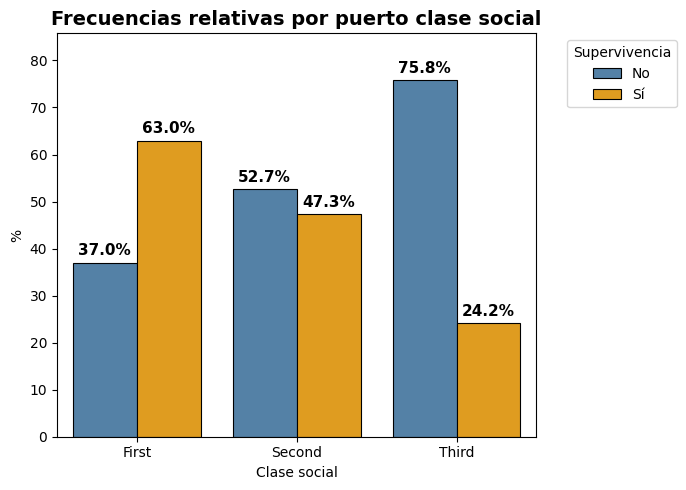

In [19]:
### FRECUENCIAS RELATIVAS ENTRE VARIABLE CATEGÓRICA Y BINARIA

variable_categorica = "class"
variable_binaria    = "alive" 
df = df_titanic.copy()

# Cambiar valores de la variable binaria a "Sí" y "No"
df[variable_binaria] = df[variable_binaria].map({"yes": "Sí", "no": "No"})

# Orden manual del hue
orden_hue = ["No", "Sí"]

# Calcular tabla de porcentajes
tabla = (
    df.groupby(variable_categorica)[variable_binaria]
      .value_counts(normalize=True)
      .rename("porcentaje")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla,
    x=variable_categorica,
    y="porcentaje",
    hue=variable_binaria,
    hue_order=orden_hue,                 # ← clave para que respete el orden
    palette=["steelblue", "orange"],     # ← colores en el mismo orden
    edgecolor="black",
    linewidth=0.8
)

plt.title("Frecuencias relativas por puerto clase social", fontsize=14, weight="bold")
plt.ylabel("%")
plt.xlabel("Clase social")

# --- Ajustar límite superior del eje Y ---
max_val = tabla["porcentaje"].max()
ax.set_ylim(0, max_val + 10)

# --- Leyenda personalizada ---
ax.legend(
    title="Supervivencia",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

# --- Añadir números encima de cada barra ---
for p in ax.patches:
    valor = p.get_height()
    if valor > 0.1:
        ax.annotate(
            f"{valor:.1f}%",
            (p.get_x() + p.get_width() / 2, valor),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.tight_layout()
plt.show()


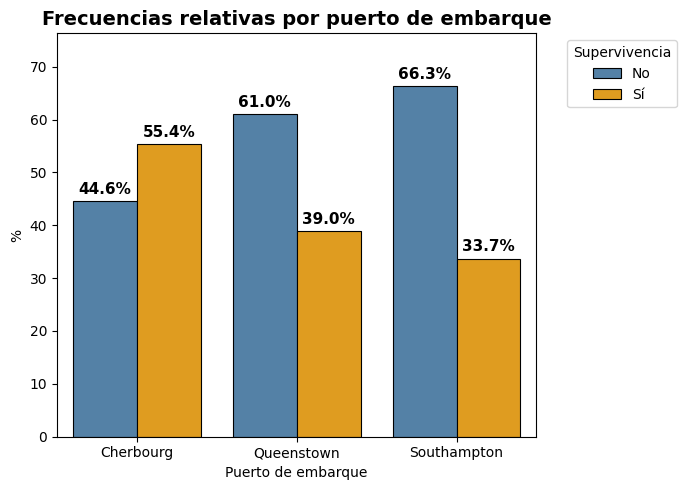

In [18]:
### FRECUENCIAS RELATIVAS ENTRE VARIABLE CATEGÓRICA Y BINARIA

variable_categorica = "embark_town"
variable_binaria    = "alive" 
df = df_titanic.copy()

# Cambiar valores de la variable binaria a "Sí" y "No"
df[variable_binaria] = df[variable_binaria].map({"yes": "Sí", "no": "No"})

# Orden manual del hue
orden_hue = ["No", "Sí"]

# Calcular tabla de porcentajes
tabla = (
    df.groupby(variable_categorica)[variable_binaria]
      .value_counts(normalize=True)
      .rename("porcentaje")
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=tabla,
    x=variable_categorica,
    y="porcentaje",
    hue=variable_binaria,
    hue_order=orden_hue,                 # ← clave para que respete el orden
    palette=["steelblue", "orange"],     # ← colores en el mismo orden
    edgecolor="black",
    linewidth=0.8
)

plt.title("Frecuencias relativas por puerto de embarque", fontsize=14, weight="bold")
plt.ylabel("%")
plt.xlabel("Puerto de embarque")

# --- Ajustar límite superior del eje Y ---
max_val = tabla["porcentaje"].max()
ax.set_ylim(0, max_val + 10)

# --- Leyenda personalizada ---
ax.legend(
    title="Supervivencia",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

# --- Añadir números encima de cada barra ---
for p in ax.patches:
    valor = p.get_height()
    if valor > 0.1:
        ax.annotate(
            f"{valor:.1f}%",
            (p.get_x() + p.get_width() / 2, valor),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.tight_layout()
plt.show()


In [21]:
def plot_categorical_vs_categorical(df, var_cat1, var_cat2,
                                    hue_order=None,
                                    palette=None,
                                    titulo=None,
                                    titulo_leyenda=None):
    """
    Grafica frecuencias relativas entre dos variables categóricas.
    """

    # Calcular tabla de porcentajes
    tabla = (
        df.groupby(var_cat1)[var_cat2]
          .value_counts(normalize=True)
          .rename("porcentaje")
          .mul(100)
          .reset_index()
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=tabla,
        x=var_cat1,
        y="porcentaje",
        hue=var_cat2,
        hue_order=hue_order,
        palette=palette,
        edgecolor="black",
        linewidth=0.8
    )

    # Títulos
    if titulo is None:
        titulo = f"Frecuencias relativas: {var_cat1} vs {var_cat2}"
    plt.title(titulo, fontsize=14, weight="bold")

    plt.ylabel("%")
    plt.xlabel(var_cat1.capitalize())

    # Ajustar límite superior del eje Y
    max_val = tabla["porcentaje"].max()
    ax.set_ylim(0, max_val + 10)

    # Leyenda
    if titulo_leyenda is None:
        titulo_leyenda = var_cat2.capitalize()

    ax.legend(
        title=titulo_leyenda,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    # Etiquetas encima de las barras
    for p in ax.patches:
        valor = p.get_height()
        if valor > 0.1:
            ax.annotate(
                f"{valor:.1f}%",
                (p.get_x() + p.get_width() / 2, valor),
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                xytext=(0, 3),
                textcoords="offset points"
            )

    plt.tight_layout()
    plt.show()


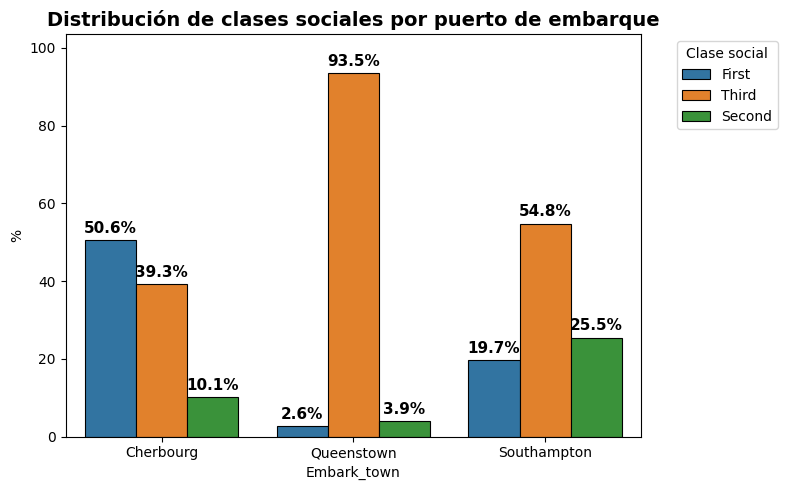

In [22]:
plot_categorical_vs_categorical(
    df=df_titanic,
    var_cat1="embark_town",
    var_cat2="class",
    titulo="Distribución de clases sociales por puerto de embarque",
    titulo_leyenda="Clase social"
)
